# Audio Quality Classification - Train Models
Goal: Train model to predict voice or voice + banging using audio features extracted from audio files

Groups:

0. Single child voice. Files gathered from many different open-source/creative commons 0 data sources of kids reading / speaking sponteneously and checked for loud background noise or banging sounds to ensure there were none.
1. Child voice + banging sounds. 48 files from group 0 were artificially combined with 10 different banging/mic bump audio from (FreeSound.org)[FreeSound.org] with creative commons 0 license for commercial use. The remaining files were gathered from open-source sources that did have loud banging sounds because they were recorded in a noisy classroom, and also have multiple voices in the background.

Time-Domain Predictors: 
 - rms_avg: Root-mean-square energy (RMS) gives an estimate of loudness, and is less sensitive to outliers than amplitude envelope
 - rms_max: Gives a sense of the loudest sound in the recording
 - zcr_avg: Zero-crossing rate (ZCR) measures the number of times an audio signal crosses the horizontal axis. The horizontal axis represents an amplitude of 0. Speech tends to have a higher ZCR than music, singing, or periods of silence, so ZCR can be a rough way to detect different types of sound. 

Frequency-Domain Predictors: 
 - mfcc1-3_avg: lower-order Mel-Frequency Cepstral Coefficients give the general shape of the spectral envelope, capturing broad low-frequency spectral trends like overall energy distribution, loudness, timbre
 - mfcc4-9_avg: middle-order Mel-Frequency Cepstral Coefficients give finer details about spectral shape like locations and relationships of formants in the spectrum that distinguish between different sounds based on how the vocal tract was shaped
 - sc_avg: Spectral centroid gives a kind of average of the frequencies
 

Data source:

Feature extraction was run on all 140 files using analysis/feature_extraction.py and extract_features_on_many_files.py to create data/output.csv. Then data was explored/cleaned/split 25%-75% for logistic regression in data_preparation_exploration.ipynb

Models Trained:
1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting
4. K-Nearest Neighbors

Date last updated: 14May26

Author: Kay Rubio

In [ ]:
#!pip install seaborn
# !pip install optuna

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
  Using cached https://nexus.cainc.com/repository/pypi/packages/alembic/1.18.4/alembic-1.18.4-py3-none-any.whl (263 kB)
  Using cached https://nexus.cainc.com/repository/pypi/packages/colorlog/6.10.1/colorlog-6.10.1-py3-none-any.whl (11 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.4 MB/s eta 0:00:00
  Using cached https://nexus.cainc.com/repository/pypi/packages/tqdm/4.67.3/tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached https://nexus.cainc.com/repository/pypi/packages/pyyaml/6.0.3/pyyaml-6.0.3-cp312-cp312-macosx_11_0_arm64.whl (173 kB)

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import optuna
import time
import os
import sys
from pathlib import Path
# ignore future warnings that aren't necessary for this project
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helper methods for classification tasks

In [32]:
def show_confusion_matrix(y_pred):
  cmat = confusion_matrix(y_test, y_pred)
  ax = plt.axes()
  sns.heatmap(cmat, ax = ax,annot=True , fmt = '.4g')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()

In [33]:
def describe_model_results(model, y_pred):
  accuracy = round(accuracy_score(y_test, y_pred)*100, 3)
  precision = round(precision_score(y_test, y_pred)*100, 3)
  recall = round(recall_score(y_test, y_pred)*100, 3)
  print('{} found accuracy: {}%, precision: {}%, recall: {}%'.format(model, accuracy, precision, recall))

## Get data

In [ ]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/KRubio/.pyenv/versions/3.12.7/lib/python312.zip', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12/lib-dynload', '', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification']


In [ ]:
# import data
x_train = pd.read_csv("../data/x_train.csv")
y_train = pd.read_csv("../data/y_train.csv")
x_test = pd.read_csv("../data/x_test.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [83]:
# Import data with filenames included
df_final = pd.read_csv("../data/df_final.csv")

In [71]:
y_test

,Unnamed: 0,group
0,6,0
1,96,1
2,91,0
3,94,1
4,29,0
5,36,0
6,74,0
7,27,0
8,35,0
9,42,0


In [ ]:
# Make a copy of the original y_test data so you have the original indices
y_test_raw = y_test.copy()

In [76]:
# drop the ID columns from the datasets
x_train.drop('Unnamed: 0', axis=1, inplace=True) 
y_train.drop('Unnamed: 0', axis=1, inplace=True) 
x_test.drop('Unnamed: 0', axis=1, inplace=True) 
y_test.drop('Unnamed: 0', axis=1, inplace=True) 


In [77]:
y_test.head()

,group
0,0
1,1
2,0
3,1
4,0


In [63]:
x_train.head()

,zcr_avg,mfcc1_avg,mfcc2_avg,mfcc3_avg,mfcc4_avg,mfcc5_avg,mfcc6_avg,mfcc7_avg,mfcc8_avg,mfcc9_avg,sc_avg,rms_avg_log,rms_max_log
0,0.134992,85.582700,1.109894,5.688129,-10.432502,-1.882168,-2.419470,-4.729365,-1.392206,-3.438150,1926.674622,0.044410,0.232411
1,0.044383,69.816810,39.112120,39.493126,26.549940,27.753954,15.996812,19.349571,14.179629,14.992563,1051.189387,0.055491,0.429079
2,0.183308,52.473870,-31.761097,-17.441038,-35.067300,-22.393587,-28.769196,-7.569713,-17.168749,-12.398012,2266.643150,0.024106,0.102122
3,0.141939,68.011500,5.066758,35.709270,-16.945522,9.422390,-12.655683,8.170222,-4.186699,2.222491,1929.928024,0.124994,0.487216
4,0.091965,84.404724,14.719588,48.276028,-3.179146,14.645829,3.053553,1.850143,2.609723,2.606381,1298.583999,0.066895,0.394852


## Logistic Regression

In [ ]:
def objective(trial):
  C = trial.suggest_float('C', 0.01, 10.0, log=True)
  solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
  lr = LogisticRegression(C=C, solver=solver, max_iter=1000)
  return cross_val_score(lr, x_train, y_train, cv=5, scoring='accuracy').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-05-14 14:42:58,106] A new study created in memory with name: no-name-dd313f96-db18-48fc-a1ab-ba55b459fdc1


/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/KRubio/CA_Repos/kays_repos/aud

In [24]:
best_params = study.best_params
print("Best parameters:", best_params)

Best parameters: {'C': 0.28850152489674596, 'solver': 'lbfgs'}


In [ ]:
# Retrain on full training set using best params found by Optuna
lr_best = LogisticRegression(
    C=best_params['C'],
    solver=best_params['solver'],
    max_iter=1000
)
lr_best.fit(x_train, y_train)

/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.28850152489674596
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.

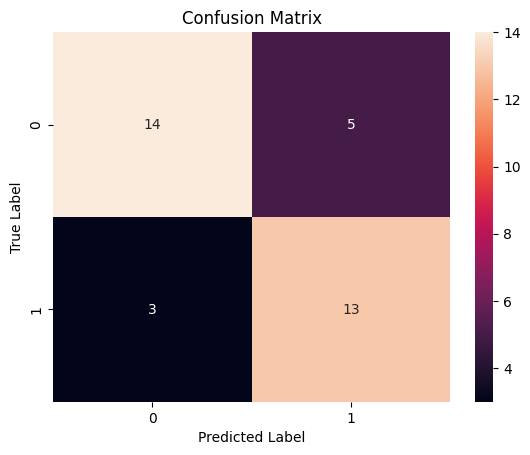

Logistic Regression found accuracy: 77.143%, precision: 72.222%, recall: 81.25%


In [ ]:
# Use model to predict values on the test and show confusion matrix and other metrics
y_pred_lr_best = lr_best.predict(x_test)
show_confusion_matrix(y_pred_lr_best)
describe_model_results('Logistic Regression', y_pred_lr_best)

These results are not perfect
 - 5/19 voice-only files were incorrectly said to have banging sounds (26%)
 - 3/16 voice+banging files were incorrectly said to be voice-only (19%)

In [ ]:
# Coefficients
coefficients = lr_best.coef_
intercept = lr_best.intercept_
for feature, coef in zip(x_train.columns, coefficients[0]):
    flag = " ***" if abs(coef) < 0.05 else ""
    print(f"{feature}: {coef}{flag}")
print(f"Intercept: {intercept}")

zcr_avg: -0.19955714135908514
mfcc1_avg: 0.05550996466958829
mfcc2_avg: -0.01071675577659128 ***
mfcc3_avg: -0.01653766450166559 ***
mfcc4_avg: 0.08618359234287874
mfcc5_avg: 0.03593904446170908 ***
mfcc6_avg: 0.05191415808875325
mfcc7_avg: 0.02988644192986496 ***
mfcc8_avg: -0.04422748749496876 ***
mfcc9_avg: 0.08436219024030603
sc_avg: 0.0019453995926595482 ***
rms_avg_yj: 0.47434375555702823
rms_max_yj: 0.6642026703441959
Intercept: [-5.84124372]


Only 6 / 13 predictors were significant in the model, so the model may benefit from their removal. Trying again with only the signficant ones

In [43]:
significant_predictors = ['mfcc2_avg', 'mfcc3_avg', 'mfcc5_avg', 'mfcc7_avg', 'mfcc8_avg', 'sc_avg']
x_train_reduced = x_train[significant_predictors]
x_test_reduced = x_test[significant_predictors]
x_train_reduced.head()

,mfcc2_avg,mfcc3_avg,mfcc5_avg,mfcc7_avg,mfcc8_avg,sc_avg
0,1.109894,5.688129,-1.882168,-4.729365,-1.392206,1926.674622
1,39.112120,39.493126,27.753954,19.349571,14.179629,1051.189387
2,-31.761097,-17.441038,-22.393587,-7.569713,-17.168749,2266.643150
3,5.066758,35.709270,9.422390,8.170222,-4.186699,1929.928024
4,14.719588,48.276028,14.645829,1.850143,2.609723,1298.583999


In [ ]:
# Retrain on reduced number of predictors with best params
lr_reduced.fit(x_train_reduced, y_train)

/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.28850152489674596
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.

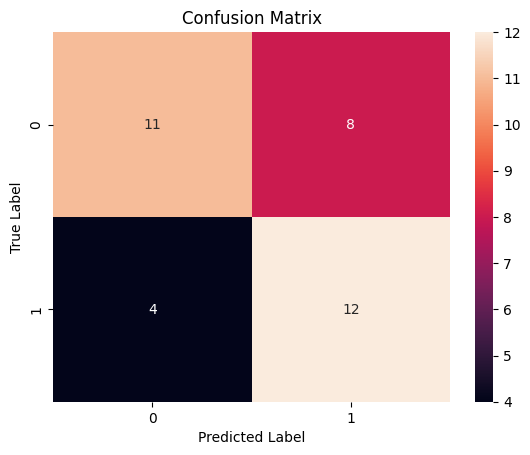

Logistic Regression found accuracy: 65.714%, precision: 60.0%, recall: 75.0%


In [ ]:
# Use model to predict values on the test and show confusion matrix and other metrics
y_pred_lr_reduced = lr_reduced.predict(x_test_reduced)
show_confusion_matrix(y_pred_lr_reduced)
describe_model_results('Logistic Regression', y_pred_lr_reduced)

## Random Forest Classifier

In [64]:
def objective(trial):
  n_estimators = trial.suggest_categorical('n_estimators', [5, 50, 100, 200])
  max_depth = trial.suggest_categorical('max_depth', [2, 10, 20, None])
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
  max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

  rf = RandomForestClassifier(
      n_estimators=n_estimators,
      max_depth=max_depth,
      min_samples_leaf=min_samples_leaf,
      max_features=max_features,
      random_state=42
  )
  return cross_val_score(rf, x_train, y_train, cv=5, scoring='accuracy').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
print("Best parameters:", best_params)

[I 2026-05-14 16:01:42,274] A new study created in memory with name: no-name-3526ce30-4eb4-4d7d-bb79-2a41d9f6b0a8
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_sam

Best parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


In [65]:
# Retrain on full training set using best params found by Optuna
rf = RandomForestClassifier(**best_params, random_state=42)
rf.fit(x_train, y_train)

/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

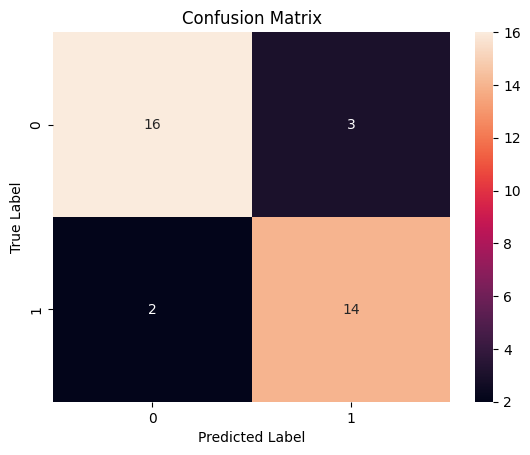

Random Forest found accuracy: 85.714%, precision: 82.353%, recall: 87.5%


In [67]:
y_pred_rf = rf.predict(x_test)
show_confusion_matrix(y_pred_rf)
describe_model_results('Random Forest', y_pred_rf)

Random Forest with all predictors is definitely an improvement above logistic regression, but it still misclassified a small number in both groups.

In [ ]:
def detect_missclassification(group, predicted_label):
  if group == 0 and predicted_label == 1:
    return 'misclassified_as_banging'
  elif group == 1 and predicted_label == 0:
    return 'misclassified_without_banging'
  else:
    return ''
comparing_results = y_test_raw.copy()
comparing_results['predicted_label'] = y_pred_rf
comparing_results['misclassified'] = comparing_results.apply(lambda row: detect_missclassification(row['group'], row['predicted_label']), axis=1)
comparing_results

,Unnamed: 0,group,predicted_label,misclassified
0,6,0,0,
1,96,1,1,
2,91,0,0,
3,94,1,1,
4,29,0,0,
5,36,0,0,
6,74,0,0,
7,27,0,0,
8,35,0,0,
9,42,0,0,


In [89]:
misclassified_as_having_banging = [48, 8, 32]
print('misclassified as having banging')
for idx in misclassified_as_having_banging:
  print(df_final.loc[idx]['filename'])

print('---')
misclassified_as_not_having_banging = [97, 79]
print('misclassified as not having banging')
for idx in misclassified_as_not_having_banging:
  print(df_final.loc[idx]['filename'])


misclassified as having banging
car.wav
green.wav
box.wav
---
misclassified as not having banging
stripes_cane.wav
swing.wav


The 3 misclassified as having banging indeed do have banging sounds that I must have missed when making the dataset, so the model is actually quite good at finding that.

The 2 misclassified as not having banging absolutely do have quite noticeable banging, so that's a little strange

But that brings model accuracy to 94%!

## Gradient Boosting Classifier

In [51]:
def objective(trial):
    n_estimators = trial.suggest_categorical('n_estimators', [50, 100, 200, 300])
    max_depth = trial.suggest_int('max_depth', 2, 5)  # keep shallow - GBC overfits easily
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)  # stochastic boosting
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    gb = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        max_features=max_features,
        random_state=42
    )
    return cross_val_score(gb, x_train, y_train, cv=5, scoring='accuracy').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
print("Best parameters:", best_params)

[I 2026-05-14 15:16:40,411] A new study created in memory with name: no-name-3ec28bac-d346-4950-a3fa-6ae52adb59fc
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the sha

Best parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.035078940998385495, 'min_samples_leaf': 1, 'subsample': 0.6750374393197086, 'max_features': 'log2'}


In [52]:
gb = GradientBoostingClassifier(**best_params, random_state=42)
gb.fit(x_train, y_train)

/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.035078940998385495
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.6750374393197086
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in 

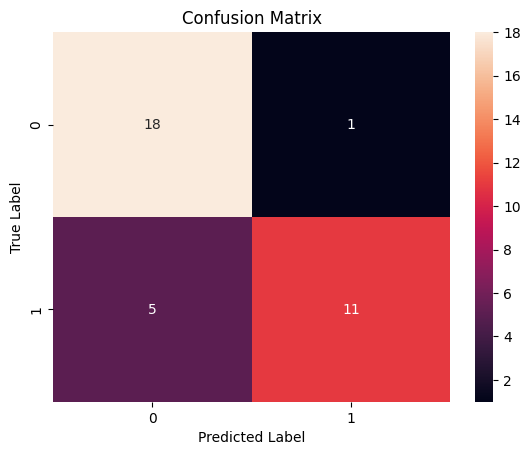

Gradient Boosting found accuracy: 82.857%, precision: 91.667%, recall: 68.75%


In [54]:
y_pred_gb = gb.predict(x_test)
show_confusion_matrix(y_pred_gb)
describe_model_results('Gradient Boosting', y_pred_gb)

## K-Nearest Neighbors Classifier

In [55]:
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 15)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])
    leaf_size = trial.suggest_int('leaf_size', 10, 50)

    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric,
        algorithm=algorithm,
        leaf_size=leaf_size
    )
    return cross_val_score(knn, x_train, y_train, cv=5, scoring='accuracy').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
print("Best parameters:", best_params)

[I 2026-05-14 15:19:53,244] A new study created in memory with name: no-name-3c3e6324-9022-4394-9a95-a15f5aa45a28
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape 

Best parameters: {'n_neighbors': 4, 'weights': 'uniform', 'metric': 'manhattan', 'algorithm': 'ball_tree', 'leaf_size': 30}


In [56]:
knn = KNeighborsClassifier(**best_params)
knn.fit(x_train, y_train)

/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'ball_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


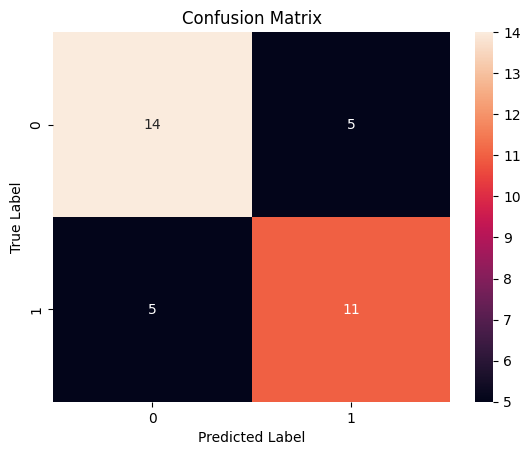

KNN found accuracy: 71.429%, precision: 68.75%, recall: 68.75%


In [57]:
y_pred_knn = knn.predict(x_test)
show_confusion_matrix(y_pred_knn)
describe_model_results('KNN', y_pred_knn)

## Save best model

In [68]:
# pickle the best model which was random forest and save to a file
joblib.dump(rf, '../models/RandomForestClassifier.pkl')

['../models/RandomForestClassifier.pkl']